In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [8]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


def separate_futr_label(data, label_column):
    futr = data.drop(columns=[label_column])
    label = data[label_column]
    return futr, label


def calculate_rmse(model, futr, label):
    predict = model.predict(futr)
    rmse = mean_squared_error(label, predict, squared=False)
    return rmse


def split(data):
    train, test = train_test_split(data, test_size=0.2, random_state=70)
    return train, test


def load_and_display_data(file_path="winequality-red.csv", sample_size=20):
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

    # Download dataset automatically if it does not exist
    if not os.path.exists(file_path):
        print("Dataset not found. Downloading automatically...")
        df = pd.read_csv(url, sep=";")
        df.to_csv(file_path, sep=";", index=False)
        print(f"Dataset downloaded and saved as: {file_path}")
    else:
        print("Dataset found locally. Loading from file...")
        df = pd.read_csv(file_path, sep=";")

    random_sample = df.sample(n=sample_size, random_state=70)
    print(random_sample)

    return df


if __name__ == "__main__":
    df = load_and_display_data("winequality-red.csv")

    train, test = split(df)

    train_futr, train_label = separate_futr_label(train, "quality")
    test_futr, test_label = separate_futr_label(test, "quality")

    print("Train shape:", train.shape)
    print("Test shape:", test.shape)

Dataset not found. Downloading automatically...
Dataset downloaded and saved as: winequality-red.csv
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
728             6.4             0.570         0.02             1.8      0.067   
779             7.1             0.520         0.03             2.6      0.076   
1206            7.2             0.360         0.46             2.1      0.074   
298             7.2             0.650         0.02             2.3      0.094   
370             6.9             0.765         0.02             2.3      0.063   
1413            9.9             0.570         0.25             2.0      0.104   
951             8.3             0.280         0.48             2.1      0.093   
450            11.9             0.390         0.69             2.8      0.095   
1032            8.1             0.820         0.00             4.1      0.095   
1449            7.2             0.380         0.31             2.0      0.056   
505     

In [31]:

#rmse
def rmse(model, futr, label):
    predict = model.predict(futr)
    mse = mean_squared_error(label, predict)
    return np.sqrt(mse)


In [32]:


#REGRESSION (ElasticNet )
train_rg_futr, train_rg_label = separate_futr_label(train, label_column="quality")

scaler_rg = StandardScaler()
scaled_train_rg_futr = scaler_rg.fit_transform(train_rg_futr)

elastic_net_model = ElasticNet()
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    elastic_net_model.fit(scaled_train_rg_futr, train_rg_label)

train_elastic_net_rmse = rmse(elastic_net_model, scaled_train_rg_futr, train_rg_label)
print(f"ElasticNet RMSE for TRAIN: {train_elastic_net_rmse}")

ElasticNet RMSE for TRAIN: 0.8142441467673188


In [33]:
#CLASSIFICATION (LogisticRegression)
train_class_futr, train_class_label = separate_futr_label(train, label_column="quality")
scaler_class = StandardScaler()
scaled_train_class_futr = scaler_class.fit_transform(train_class_futr)
log_rg_model = LogisticRegression()
log_rg_model.fit(scaled_train_class_futr, train_class_label)
log_rg_train_predictions = log_rg_model.predict(scaled_train_class_futr)
log_rg_train_accuracy = accuracy_score(train_class_label, log_rg_train_predictions)
print(f"Logistic Regression Accuracy for TRAIN: {log_rg_train_accuracy}")

Logistic Regression Accuracy for TRAIN: 0.6043784206411259


In [34]:
#test
test_rg_futr, test_rg_label = separate_futr_label(test, label_column="quality")
scaled_test_rg_futr = scaler_rg.transform(test_rg_futr)

test_elastic_net_rmse = rmse(elastic_net_model, scaled_test_rg_futr, test_rg_label)
print(f"ElasticNet RMSE for TEST: {test_elastic_net_rmse}")

test_class_futr, test_class_label = separate_futr_label(test, label_column="quality")
scaled_test_class_futr = scaler_class.transform(test_class_futr)
log_rg_test_predict = log_rg_model.predict(scaled_test_class_futr)
log_rg_test_accuracy = accuracy_score(test_class_label, log_rg_test_predict)
print(f"Logistic Rgression Accuracy for TEST: {log_rg_test_accuracy}")


ElasticNet RMSE for TEST: 0.7794282047595079
Logistic Rgression Accuracy for TEST: 0.60625


In [35]:
# CLASSIFICATION (K-nearest neighbors)
train_class_futr, train_class_label = separate_futr_label(train, label_column="quality")
scaler_class = StandardScaler()
scaled_train_class_futr = scaler_class.fit_transform(train_class_futr)
knn_model = KNeighborsClassifier(n_neighbors=7, algorithm='auto', weights='uniform')
knn_model.fit(scaled_train_class_futr, train_class_label)
knn_train_predictions = knn_model.predict(scaled_train_class_futr)
knn_train_accuracy = accuracy_score(train_class_label, knn_train_predictions)
print(f"K-Nearest Neighbors Accuracy for TRAIN: {knn_train_accuracy}")

K-Nearest Neighbors Accuracy for TRAIN: 0.6763096168881939


In [36]:
#KNN Accuracy for Test
test_class_futr, test_class_label = separate_futr_label(test, label_column="quality")
scaled_test_class_futr = scaler_class.transform(test_class_futr)
knn_test_predict = knn_model.predict(scaled_test_class_futr)
knn_test_accuracy = accuracy_score(test_class_label, knn_test_predict)
print(f"K-Nearest Neighbors Accuracy for TEST: {knn_test_accuracy}")

K-Nearest Neighbors Accuracy for TEST: 0.615625


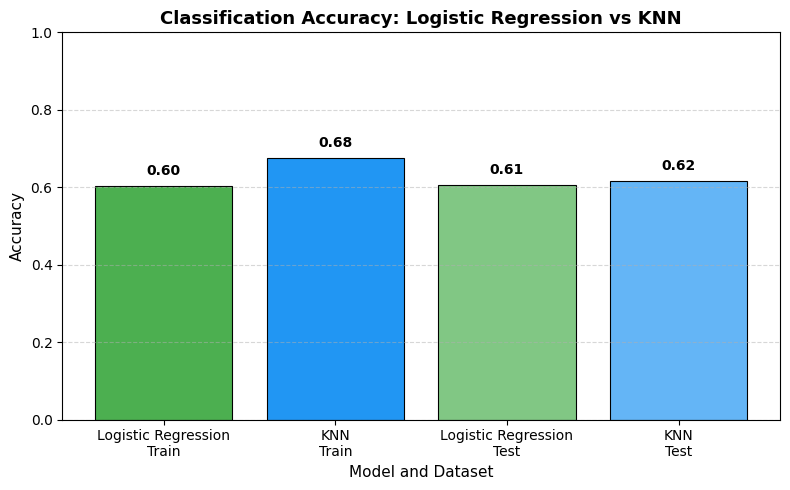

In [39]:
import matplotlib.pyplot as plt

# Accuracy values
accuracy_values = [
    log_rg_train_accuracy,
    knn_train_accuracy,
    log_rg_test_accuracy,
    knn_test_accuracy
]

labels = [
    "Logistic Regression\nTrain",
    "KNN\nTrain",
    "Logistic Regression\nTest",
    "KNN\nTest"
]

colors = ["#4CAF50", "#2196F3", "#81C784", "#64B5F6"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    accuracy_values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

plt.ylim(0, 1)
plt.title("Classification Accuracy: Logistic Regression vs KNN", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy", fontsize=11)
plt.xlabel("Model and Dataset", fontsize=11)

# Add values on top of bars
for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()